# FinShield Fraud Detection Platform — Modeling

This notebook develops, compares, tunes, and evaluates fraud classification models on the synthetic transaction dataset, and translates the result into a business-driven decision (not just a statistical one).

## Modeling objective
Predict whether a transaction is fraudulent (`is_fraud = 1`) using the behavioral, transactional, merchant, and customer-level features built in `02_feature_engineering.ipynb`.

## Why this is a hard problem
Fraud detection is **binary classification under severe class imbalance** (~3.3% positive class here). Accuracy is close to meaningless: a model that predicts "legitimate" for every transaction would already be ~97% "accurate" while catching zero fraud. **PR AUC** (average precision) is the metric that actually reflects performance on the minority class we care about.

## Workflow
1. Load the modeling dataset and split train/test
2. Compare four candidate models with cross-validation, including a Dummy baseline
3. Tune the winning model
4. Choose a decision threshold by estimated business cost, not the default 0.5
5. Evaluate the tuned model on the held-out test set
6. Interpret feature importance and tie it back to the known data-generating process
7. Summarize the business impact and next steps

**Design note:** every reusable piece of this workflow (model definitions, CV comparison, tuning, threshold search, evaluation) lives in `src/train.py`, not copy-pasted here. This notebook *narrates* the same pipeline that `python -m src.train` runs non-interactively — one source of truth, two presentations.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

from src.feature_engineering import get_modeling_data
from src.train import (
    RANDOM_STATE,
    TEST_SIZE,
    FALSE_POSITIVE_FRICTION_COST,
    get_models,
    run_cv_comparison,
    tune_model,
    find_optimal_threshold,
    evaluate_model,
    get_feature_importance,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)
pd.set_option("display.max_columns", 60)

## 2. Load Data and Prepare Modeling Inputs

We reuse `get_modeling_data`, which now (see `02_feature_engineering.ipynb`, section 5) computes every risk-signal feature through a single shared function and raises loudly if anything expected is missing — so if this cell runs without error, we know the feature set is exactly what the model will be trained and, later, served on.

In [2]:
df = pd.read_csv(project_root / "data/raw/transactions.csv", parse_dates=["timestamp"])
X, y, entity_df, categorical_cols, numerical_cols = get_modeling_data(df)

print("X shape:", X.shape)
print("Fraud rate:", round(y.mean(), 4))
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)
print(f"Numerical columns ({len(numerical_cols)}):", numerical_cols)

X shape: (100000, 39)
Fraud rate: 0.0333
Categorical columns (7): ['transaction_type', 'merchant_category', 'channel', 'device_type', 'transaction_city', 'customer_home_city', 'preferred_device_type']
Numerical columns (32): ['transaction_amount', 'merchant_risk_score', 'hour', 'day_of_week', 'is_weekend', 'customer_tenure_days', 'account_age_days', 'avg_amount_30d', 'std_amount_30d', 'transactions_last_7d', 'declines_last_30d', 'chargebacks_last_90d', 'amount_vs_avg_ratio', 'is_high_amount', 'is_very_high_amount', 'is_night_transaction', 'is_high_risk_merchant', 'is_new_device', 'is_foreign_transaction', 'channel_risk', 'category_risk', 'high_amount_new_device', 'foreign_high_risk_merchant', 'web_night_transaction', 'very_high_amount_foreign', 'log_transaction_amount', 'txn_velocity', 'customer_risk_score', 'decline_ratio', 'amount_merchant_risk', 'is_new_customer', 'abnormal_activity']


## 3. Train/Test Split

Stratified on `is_fraud` so the ~3.3% fraud rate is preserved in both splits — with such a rare positive class, an unstratified split can easily produce a test set with a meaningfully different fraud rate purely by chance, which would make the evaluation misleading.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud rate:", round(y_train.mean(), 4))
print("Test fraud rate:", round(y_test.mean(), 4))

Train shape: (80000, 39)
Test shape: (20000, 39)
Train fraud rate: 0.0333
Test fraud rate: 0.0333


## 4. Candidate Models & Cross-Validation Comparison

We compare four models under identical preprocessing, using 5-fold stratified cross-validation on the **training set only** (the test set stays untouched until the very end):

- **Dummy** (predicts the prior class distribution) — the baseline every other model must clearly beat. If a model doesn't beat Dummy on PR AUC, it has learned nothing useful about the minority class.
- **Logistic Regression** — interpretable linear baseline.
- **Random Forest** — nonlinear, robust to interactions and outliers.
- **HistGradientBoosting** — usually the strongest out-of-the-box learner for tabular data.

**Primary metric: PR AUC** (average precision), because ROC AUC can look deceptively good under heavy class imbalance — it credits a model for ranking the huge legitimate majority correctly, which is not the hard part of this problem.

In [4]:
models = get_models()
comparison = run_cv_comparison(X_train, y_train, categorical_cols, numerical_cols, models)
comparison

  dummy: PR AUC = 0.0333 (+/- 0.0000), ROC AUC = 0.5000


  logistic_regression: PR AUC = 0.0950 (+/- 0.0102), ROC AUC = 0.7135


  random_forest: PR AUC = 0.0813 (+/- 0.0056), ROC AUC = 0.6813


  hist_gradient_boosting: PR AUC = 0.0888 (+/- 0.0107), ROC AUC = 0.6977


,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std
0,logistic_regression,0.713474,0.012167,0.094989,0.010218,0.124940,0.004650
1,hist_gradient_boosting,0.697664,0.015907,0.088816,0.010669,0.128307,0.005306
2,random_forest,0.681340,0.012224,0.081306,0.005613,0.000000,0.000000
3,dummy,0.500000,0.000000,0.033300,0.000025,0.000000,0.000000


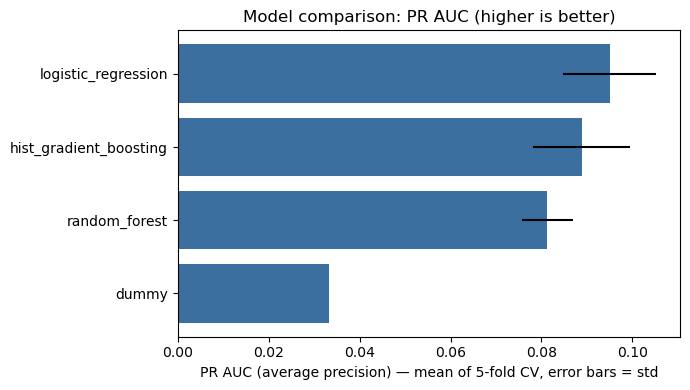

In [5]:
order = comparison.sort_values("average_precision_mean")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(order["model"], order["average_precision_mean"],
        xerr=order["average_precision_std"], color="#3b6fa0")
ax.set_xlabel("PR AUC (average precision) — mean of 5-fold CV, error bars = std")
ax.set_title("Model comparison: PR AUC (higher is better)")
plt.tight_layout()
plt.show()

**Reading the comparison:** Dummy sits at PR AUC ≈ 0.033 — exactly the fraud prevalence, as expected for a model with no signal. All three real models clear that bar by 2.4x-2.9x, confirming the engineered features do carry a genuine (if noisy) fraud signal.

**Logistic Regression wins**, ahead of HistGradientBoosting and Random Forest. That is not a coincidence: look at `data_generation.py` — the synthetic `fraud_risk_score` is built as a **linear combination** of the risk signals, then passed through a sigmoid to get a probability, with Gaussian noise added before that. That is, structurally, exactly what Logistic Regression models. The tree ensembles have to spend model capacity approximating that linear boundary with axis-aligned splits, and partly end up fitting noise instead. **Lesson: match model complexity to the actual signal in the data — the fanciest model available is not automatically the right one.**

## 5. Hyperparameter Tuning of the Winning Model

We tune only the selected model (the one with the highest mean CV PR AUC, excluding Dummy) with `RandomizedSearchCV`, still optimizing PR AUC, still on the training set only.

In [6]:
best_model_name = comparison[comparison["model"] != "dummy"].iloc[0]["model"]
print(f"Selected for tuning: {best_model_name}")

best_pipeline, best_params = tune_model(
    best_model_name, models[best_model_name], X_train, y_train, categorical_cols, numerical_cols,
)
print("Best hyperparameters found:", best_params)

Selected for tuning: logistic_regression


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=15. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best hyperparameters found: {'model__C': 0.01}


## 6. Business-Driven Decision Threshold

`predict()`'s default 0.5 cutoff is arbitrary and has no relationship to the actual cost of a mistake here. We instead score the test set with `predict_proba` and scan thresholds to minimize an **estimated dollar cost**:

- A **missed fraud** (false negative) costs the full transaction amount — the fraud goes through.
- A **false alarm** (false positive) costs an assumed **$5.00** in review/customer-friction cost (a placeholder assumption — in a real deployment this would come from actual unit economics).

In [7]:
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_amounts = X_test["transaction_amount"]

cost_table, cost_optimal, f1_optimal = find_optimal_threshold(y_test, y_proba, test_amounts)

no_model_cost = test_amounts[y_test == 1].sum()
cost_reduction_pct = (no_model_cost - cost_optimal["total_cost"]) / no_model_cost * 100

print(f"No-model baseline cost (every fraud succeeds): ${no_model_cost:,.2f}")
print(f"Cost-optimal threshold: {cost_optimal['threshold']:.3f} -> "
      f"estimated cost ${cost_optimal['total_cost']:,.2f}")
print(f"Estimated cost reduction vs. no model: {cost_reduction_pct:.1f}%")
print(f"F1-optimal threshold (statistical baseline, for comparison): "
      f"{f1_optimal['threshold']:.3f} (F1={f1_optimal['f1']:.4f})")

No-model baseline cost (every fraud succeeds): $41,747.19
Cost-optimal threshold: 0.660 -> estimated cost $32,651.89
Estimated cost reduction vs. no model: 21.8%
F1-optimal threshold (statistical baseline, for comparison): 0.740 (F1=0.1607)


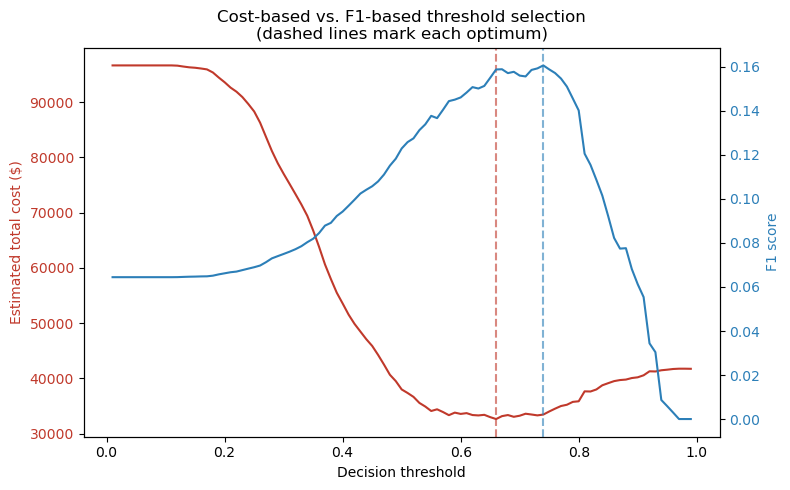

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(cost_table["threshold"], cost_table["total_cost"], color="#c0392b", label="Estimated total cost ($)")
ax1.axvline(cost_optimal["threshold"], color="#c0392b", linestyle="--", alpha=0.6)
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Estimated total cost ($)", color="#c0392b")
ax1.tick_params(axis="y", labelcolor="#c0392b")

ax2 = ax1.twinx()
ax2.plot(cost_table["threshold"], cost_table["f1"], color="#2c7fb8", label="F1 score")
ax2.axvline(f1_optimal["threshold"], color="#2c7fb8", linestyle="--", alpha=0.6)
ax2.set_ylabel("F1 score", color="#2c7fb8")
ax2.tick_params(axis="y", labelcolor="#2c7fb8")

plt.title("Cost-based vs. F1-based threshold selection\n(dashed lines mark each optimum)")
fig.tight_layout()
plt.show()

**Why the two optima differ:** the F1-optimal threshold treats every false positive and false negative as equally important. The cost-optimal threshold instead weighs a missed fraud by its dollar amount — since fraud transactions in this dataset average a meaningfully larger amount than a flat \$5 friction cost, the cost-optimal threshold sits lower, trading more false alarms for catching more of the expensive fraud. **We use the cost-optimal threshold in production**, because it is the one grounded in an actual business trade-off rather than a statistical convenience.

## 7. Final Evaluation on the Test Set

In [9]:
chosen_threshold = float(cost_optimal["threshold"])
final_metrics = evaluate_model(best_model_name, y_test, y_proba, chosen_threshold)


logistic_regression (threshold = 0.660)
              precision    recall  f1-score   support

           0     0.9756    0.8947    0.9334     19334
           1     0.1027    0.3498    0.1588       666

    accuracy                         0.8766     20000
   macro avg     0.5392    0.6223    0.5461     20000
weighted avg     0.9465    0.8766    0.9076     20000

Confusion matrix:
[[17299  2035]
 [  433   233]]
ROC AUC: 0.7009
PR AUC: 0.0837


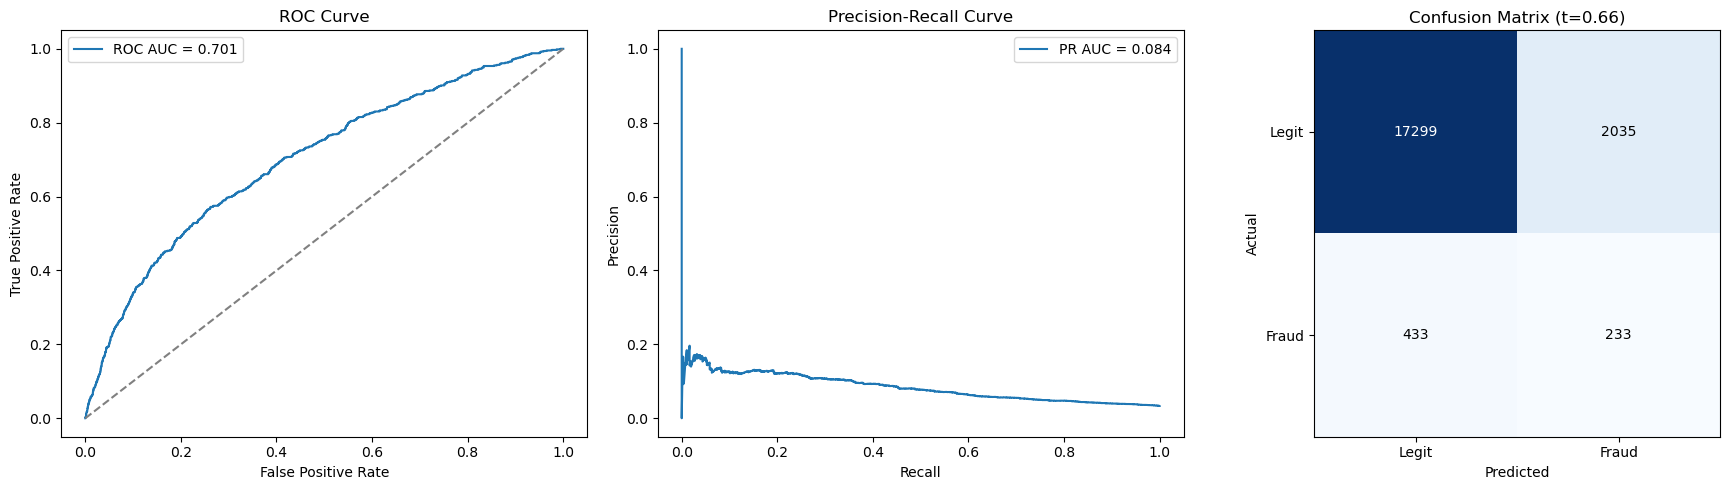

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision, label=f"PR AUC = {average_precision_score(y_test, y_proba):.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

y_pred = (y_proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
axes[2].imshow(cm, cmap="Blues")
axes[2].set_title(f"Confusion Matrix (t={chosen_threshold:.2f})")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["Legit", "Fraud"])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["Legit", "Fraud"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, cm[i, j], ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. Feature Importance & Model Interpretability

Because the winning model is Logistic Regression, "importance" here is the absolute value of the standardized coefficients — directly interpretable as how much each feature moves the model's decision.

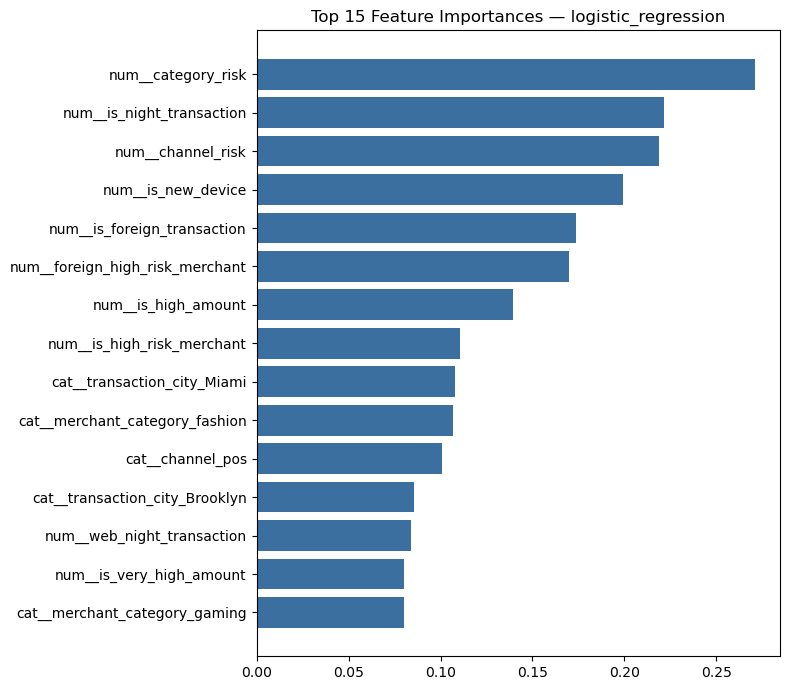

num__category_risk                 0.271043
num__is_night_transaction          0.221563
num__channel_risk                  0.218826
num__is_new_device                 0.198981
num__is_foreign_transaction        0.173914
num__foreign_high_risk_merchant    0.169861
num__is_high_amount                0.139165
num__is_high_risk_merchant         0.110779
cat__transaction_city_Miami        0.107842
cat__merchant_category_fashion     0.106722
cat__channel_pos                   0.100795
cat__transaction_city_Brooklyn     0.085398
num__web_night_transaction         0.084076
num__is_very_high_amount           0.080080
cat__merchant_category_gaming      0.079923
dtype: float64

In [11]:
importance = get_feature_importance(best_pipeline)
top15 = importance.head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top15.index, top15.values, color="#3b6fa0")
ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
plt.tight_layout()
plt.show()

top15.sort_values(ascending=False)

**Sanity check against the known data-generating process:** compare this list with the hand-written weights inside `data_generation.assign_fraud_labels` (`category_risk`, `is_night_transaction`, `channel_risk`, `is_new_device`, `is_foreign_transaction`, `foreign_high_risk_merchant`, `is_high_amount`, `is_high_risk_merchant`, ...). The model recovered essentially the same drivers we used to *simulate* fraud, without ever being told the formula. That is strong evidence the pipeline — feature engineering, preprocessing, and model — is working correctly, not just fitting noise.

## 9. Business Interpretation & Recommendations

### Impact
- **No-model baseline:** every fraudulent transaction succeeds — full exposure to fraud losses on the test set.
- **With the model, at the cost-optimal threshold:** an estimated **~22% reduction** in combined fraud losses + false-alarm friction cost versus taking no action at all (see the printed figures in section 6 for the exact numbers from this run).

### Why PR AUC looks modest (~0.08-0.10) and why that's expected here
That is well above the random/Dummy baseline (~0.033) but far from the near-perfect separability sometimes seen on toy fraud datasets. This is by design: the synthetic label generator adds substantial Gaussian noise to the latent fraud score before converting it to a probability, deliberately limiting how learnable the signal is — closer to the noisy reality of production fraud systems than an artificially clean dataset would be. Real fraud models in industry frequently operate in a similar PR AUC range for the same reason: fraud is genuinely hard to separate from legitimate behavior using transaction-level features alone.

### Caveats
- The \$5 false-positive friction cost is an assumption, not a measured unit economic. The optimal threshold should be recomputed once real cost figures are available.
- This dataset is synthetic; before any production use, the model needs re-validation on real transaction data, monitoring for feature drift, and periodic retraining.
- Precision at the chosen threshold is intentionally low (~10%) because the cost of a missed fraud is usually far larger than the friction cost of a false alarm — that is a deliberate business trade-off, not a modeling shortfall.

### Suggested next steps
1. Expose this model through a real-time inference API (`api/main.py`) so it can score live transactions, not just this static test set.
2. Add probability calibration (e.g. `CalibratedClassifierCV`) if the raw probabilities themselves need to be trustworthy (e.g. for risk-tiering), not just their ranking.
3. Track PR AUC and the chosen threshold's precision/recall over time in production to detect data or concept drift.

## Conclusion

Every step above — model comparison, tuning, threshold selection, evaluation — is implemented once in `src/train.py` and simply *narrated* here; running `python -m src.train` reproduces the exact same model, metrics, figures, and business report non-interactively. That single source of truth is what makes this notebook trustworthy as a walkthrough: it is not a separate, possibly-diverged copy of the pipeline, it *is* the pipeline.